In [1]:
import pandas as pd
import numpy as np
import random
import torch

In [2]:
import ast

In [3]:
sensitive_boundaries_results_path = "/scratch1/smaruj/sensitive_boundary_results.tsv"
df = pd.read_csv(sensitive_boundaries_results_path, sep="\t")

In [4]:
df["disrupted_bin"] = df["disrupted_bin"].apply(ast.literal_eval)

In [5]:
df

,chrom,start,end,window_end,window_start,disrupted_bin,SCD,URQ_mean_og,URQ_mean_perm
0,chr1,4400000,4410000,5061504,3750784,[261],13.902337,-0.425214,-0.402747
1,chr1,4770000,4780000,5431504,4120784,"[252, 243, 253, 258]",69.273682,-0.149015,-0.015631
2,chr1,5150000,5160000,5811504,4500784,"[247, 269]",22.719524,-0.317068,-0.263531
3,chr1,5900000,5910000,6561504,5250784,"[255, 260]",50.955429,-0.249874,-0.141139
4,chr1,6190000,6200000,6851504,5540784,[253],2.678240,-0.276848,-0.275500
...,...,...,...,...,...,...,...,...,...
3910,chr9,121450000,121460000,122111504,120800784,"[257, 266, 267]",67.525703,-0.109020,-0.026695
3911,chr9,121700000,121710000,122361504,121050784,"[251, 243]",27.691624,-0.260271,-0.228262
3912,chr9,122350000,122360000,123011504,121700784,[253],14.205888,-0.057232,-0.043494
3913,chr9,122720000,122730000,123381504,122070784,"[257, 261]",51.204041,-0.176782,-0.090296


In [6]:
import matplotlib.pyplot as plt

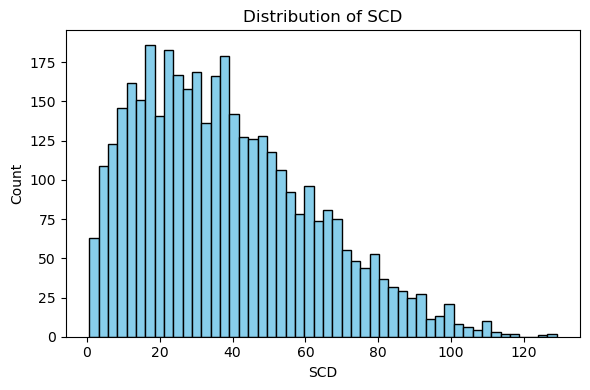

In [7]:
# Plot SCD histogram
plt.figure(figsize=(6, 4))
plt.hist(df["SCD"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of SCD")
plt.xlabel("SCD")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

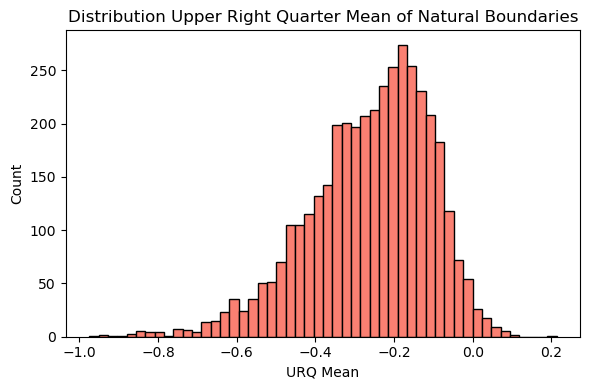

In [8]:
# Plot DeltaBoundaryStrength histogram
plt.figure(figsize=(6, 4))
plt.hist(df["URQ_mean_og"], bins=50, color="salmon", edgecolor="black")
plt.title("Distribution Upper Right Quarter Mean of Natural Boundaries")
plt.xlabel("URQ Mean")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [9]:
df["URQ_mean_og"].min(), df["URQ_mean_og"].mean()

(-0.9748536, -0.2617067170439157)

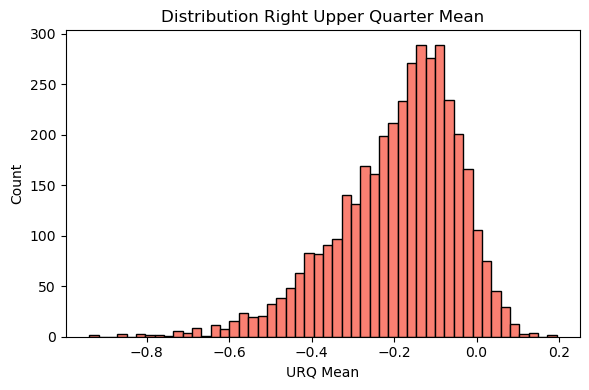

In [10]:
# Plot DeltaBoundaryStrength histogram
plt.figure(figsize=(6, 4))
plt.hist(df["URQ_mean_perm"], bins=50, color="salmon", edgecolor="black")
plt.title("Distribution Right Upper Quarter Mean")
plt.xlabel("URQ Mean")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/tmp/SLURM_1029995/ipykernel_3602063/473624609.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Before (URQ_mean_og)', 'After (URQ_mean_perm)'])


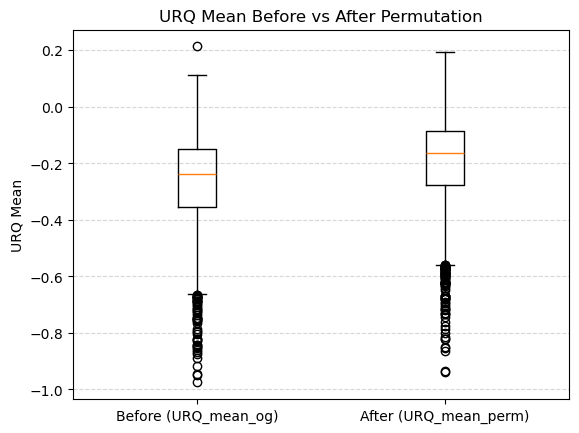

In [11]:
# Create the data in long format for boxplotting
data_to_plot = [df['URQ_mean_og'], df['URQ_mean_perm']]

# Make the boxplot
plt.boxplot(data_to_plot, labels=['Before (URQ_mean_og)', 'After (URQ_mean_perm)'])
plt.ylabel('URQ Mean')
plt.title('URQ Mean Before vs After Permutation')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## CTCFs analysis

In [12]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices, dtype=int)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    return one_hot_encoded

In [13]:
from pyfaidx import Fasta

In [14]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [15]:
def group_consecutive_bins(bins):
    bins = sorted(bins)
    grouped = []
    current_group = [bins[0]]

    for b in bins[1:]:
        if b == current_group[-1] + 1:
            current_group.append(b)
        else:
            grouped.append(current_group)
            current_group = [b]
    grouped.append(current_group)
    return grouped

In [16]:
def get_sequence(genome, chrom, start, bin_list, cropping=64, bin_size=2048):
    if len(bin_list) == 1:
        bin_start = start + (bin_list[0] + cropping) * bin_size
        bin_end = bin_start + bin_size
    else:
        bin_start = start + (min(bin_list) + cropping) * bin_size
        bin_end = bin_start + len(bin_list) * bin_size
    seq = genome[chrom][bin_start:bin_end].seq.upper()
    ohe_seq = one_hot_encode_sequence(seq)
    return np.expand_dims(ohe_seq, axis=0)

In [17]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [18]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [19]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [20]:
from tangermeme.tools import fimo

In [21]:
all_hits = []

for idx, row in df.iterrows():
    chrom = row["chrom"]
    window_start = row["window_start"]
    window_end = row["window_end"]
    scd = row["SCD"]
    og_URQ = row["URQ_mean_og"]
    perm_URQ = row["URQ_mean_perm"]
    all_bins = row["disrupted_bin"]
    grouped_bins = group_consecutive_bins(all_bins)
    
    for gr_bins in grouped_bins:
        sequence = get_sequence(genome, chrom, window_start, gr_bins)

        hits = fimo.fimo(
            motifs=motifs_dict,
            sequences=sequence,
            threshold=1e-4,
            reverse_complement=True
        )[0]

        # Only add non-empty results
        if not hits.empty:
            hits["chrom"] = chrom
            hits["window_start"] = window_start
            hits["window_end"] = window_end
            hits["bin_group"] = str(gr_bins)
            hits["scd"] = scd
            hits["URQ_mean_og"] = og_URQ
            hits["URQ_mean_perm"] = perm_URQ
            all_hits.append(hits)

In [22]:
combined_hits_df = pd.concat(all_hits, ignore_index=True)

In [23]:
combined_hits_df

,motif_name,motif_idx,sequence_name,start,end,strand,score,p-value,chrom,window_start,window_end,bin_group,scd,URQ_mean_og,URQ_mean_perm
0,CTCF,0,0,515,534,-,18.380678,4.184731e-07,chr1,3750784,5061504,[261],13.902337,-0.425214,-0.402747
1,CTCF,0,0,2103,2122,+,23.876692,1.738954e-09,chr1,4120784,5431504,"[252, 253]",69.273682,-0.149015,-0.015631
2,CTCF,0,0,590,609,-,19.636239,1.538319e-07,chr1,4120784,5431504,"[252, 253]",69.273682,-0.149015,-0.015631
3,CTCF,0,0,2228,2247,-,11.178763,2.908347e-05,chr1,4120784,5431504,"[252, 253]",69.273682,-0.149015,-0.015631
4,CTCF,0,0,35,54,-,18.985803,2.676388e-07,chr1,4120784,5431504,[258],69.273682,-0.149015,-0.015631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12981,CTCF,0,0,1988,2007,+,10.158748,4.658175e-05,chr9,122480784,123791504,"[266, 267]",42.105179,-0.146953,-0.082079
12982,CTCF,0,0,2873,2892,+,11.581269,2.393869e-05,chr9,122480784,123791504,"[266, 267]",42.105179,-0.146953,-0.082079
12983,CTCF,0,0,921,940,-,12.583158,1.446826e-05,chr9,122480784,123791504,"[266, 267]",42.105179,-0.146953,-0.082079
12984,CTCF,0,0,1130,1149,-,13.594179,8.515370e-06,chr9,122480784,123791504,"[266, 267]",42.105179,-0.146953,-0.082079


In [24]:
grouped_df = combined_hits_df.groupby(
    ["chrom", "window_start", "window_end", "scd", "URQ_mean_og", "URQ_mean_perm"], as_index=False
).agg(
    score_max=("score", "max"),
    score_sum=("score", "sum"),
    motif_count=("score", "count"),
    strand_concat=("strand", lambda x: ",".join(x.astype(str)))
)

In [25]:
grouped_df

,chrom,window_start,window_end,scd,URQ_mean_og,URQ_mean_perm,score_max,score_sum,motif_count,strand_concat
0,chr1,3750784,5061504,13.902337,-0.425214,-0.402747,18.380678,18.380678,1,-
1,chr1,4120784,5431504,69.273682,-0.149015,-0.015631,23.876692,73.677497,4,"+,-,-,-"
2,chr1,4500784,5811504,22.719524,-0.317068,-0.263531,14.961813,48.583393,4,"-,-,+,-"
3,chr1,5250784,6561504,50.955429,-0.249874,-0.141139,14.629683,45.357312,4,"+,-,+,+"
4,chr1,5540784,6851504,2.678240,-0.276848,-0.275500,12.621321,24.569232,2,"-,-"
...,...,...,...,...,...,...,...,...,...,...
3776,chr9,120800784,122111504,67.525703,-0.109020,-0.026695,22.472674,95.765660,7,"+,+,+,-,+,+,+"
3777,chr9,121050784,122361504,27.691624,-0.260271,-0.228262,25.082540,208.097929,10,"+,-,+,+,+,+,+,+,+,-"
3778,chr9,121700784,123011504,14.205888,-0.057232,-0.043494,12.602928,35.420018,3,"+,+,-"
3779,chr9,122070784,123381504,51.204041,-0.176782,-0.090296,23.762212,45.137881,2,"-,+"


In [26]:
grouped_df["motif_count"].mean(), grouped_df["motif_count"].min(), grouped_df["motif_count"].max()

(3.434541126686062, 1, 19)

In [27]:
# Filter the DataFrame for the desired RUQ_mean range
filtered_df = grouped_df[(grouped_df['URQ_mean_og'] >= -0.25) & (grouped_df['URQ_mean_og'] <= -0.15)]

# Calculate the average motif_count in this range
average_motif_count = filtered_df['motif_count'].mean()

print(f"Average motif_count for URQ_mean_og between -0.25 and -0.15: {average_motif_count}")

Average motif_count for URQ_mean_og between -0.25 and -0.15: 3.2183235867446394


In [28]:
# Filter the DataFrame for the desired URQ_mean_og range
filtered_df = grouped_df[(grouped_df['URQ_mean_og'] >= -0.35) & (grouped_df['URQ_mean_og'] <= -0.25)]

# Calculate the average motif_count in this range
average_motif_count = filtered_df['motif_count'].mean()

print(f"Average motif_count for URQ_mean_og between -0.35 and -0.25: {average_motif_count}")

Average motif_count for URQ_mean_og between -0.35 and -0.25: 3.7265060240963854


In [29]:
# Filter the DataFrame for the desired URQ_mean_og range
filtered_df = grouped_df[(grouped_df['URQ_mean_og'] >= -0.45) & (grouped_df['URQ_mean_og'] <= -0.35)]

# Calculate the average motif_count in this range
average_motif_count = filtered_df['motif_count'].mean()

print(f"Average motif_count for URQ_mean_og between -0.45 and -0.35: {average_motif_count}")

Average motif_count for URQ_mean_og between -0.45 and -0.35: 3.784499054820416


In [30]:
# Filter the DataFrame for the desired URQ_mean_og range
filtered_df = grouped_df[(grouped_df['URQ_mean_og'] >= -0.55) & (grouped_df['URQ_mean_og'] <= -0.45)]

# Calculate the average motif_count in this range
average_motif_count = filtered_df['motif_count'].mean()

print(f"Average motif_count for URQ_mean_og between -0.55 and -0.45: {average_motif_count}")

Average motif_count for URQ_mean_og between -0.55 and -0.45: 3.6952054794520546


In [31]:
def strand_bias(s):
    strands = list(s)
    if not strands:
        return 0.5
    return strands.count("+") / len(strands)

grouped_df["strand_bias"] = grouped_df["strand_concat"].apply(strand_bias)

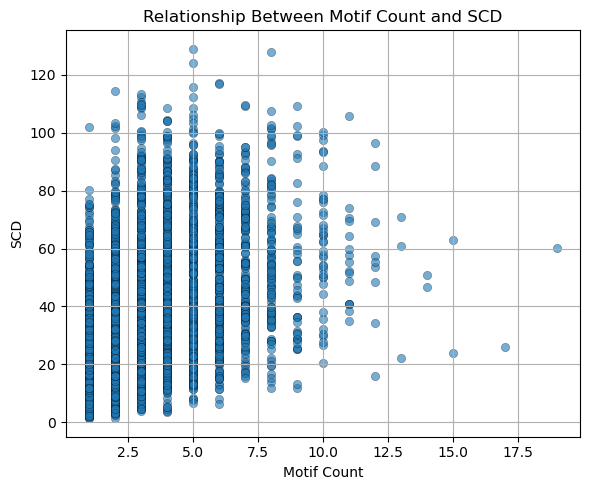

In [32]:
plt.figure(figsize=(6, 5))
plt.scatter(
    grouped_df["motif_count"],
    grouped_df["scd"],
    alpha=0.6,
    edgecolors="k",
    linewidths=0.3
)
plt.title("Relationship Between Motif Count and SCD")
plt.xlabel("Motif Count")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

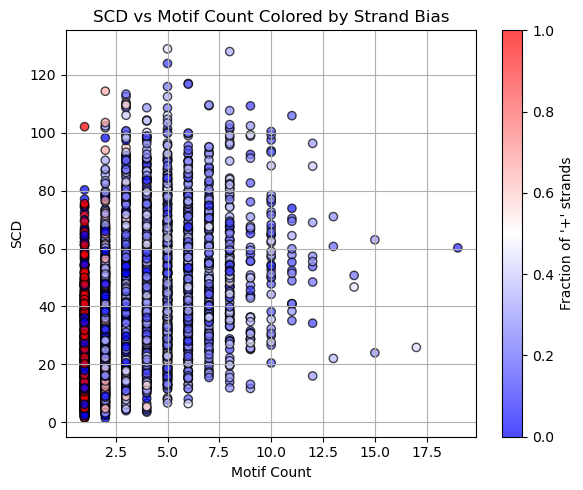

In [33]:
plt.figure(figsize=(6, 5))
plt.scatter(
    grouped_df["motif_count"],
    grouped_df["scd"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")
plt.title("SCD vs Motif Count Colored by Strand Bias")
plt.xlabel("Motif Count")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

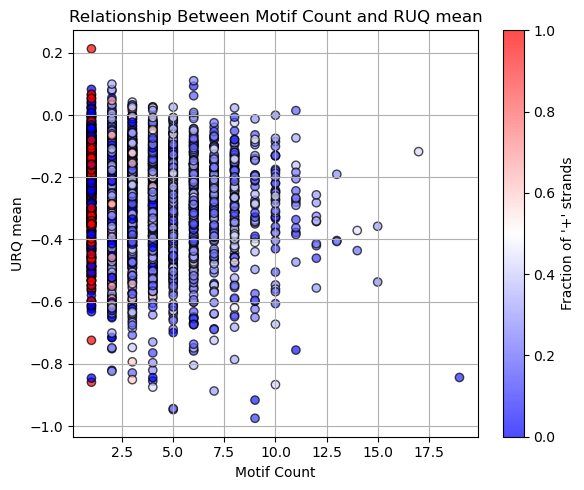

In [34]:
plt.figure(figsize=(6, 5))
plt.scatter(
    grouped_df["motif_count"],
    grouped_df["URQ_mean_og"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")
plt.title("Relationship Between Motif Count and RUQ mean")
plt.xlabel("Motif Count")
plt.ylabel("URQ mean")
plt.grid(True)
plt.tight_layout()
plt.show()

### SCD vs. FIMO score (sum and max)

In [35]:
from scipy.stats import pearsonr

# Compute Pearson correlation
r, p = pearsonr(grouped_df["score_max"], grouped_df["scd"])
corr_text = f"r = {r:.2f}, p = {p:.2e}"

In [36]:
corr_text

'r = 0.41, p = 9.18e-154'

In [37]:
x = grouped_df["score_max"]
y = grouped_df["scd"]

# Fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

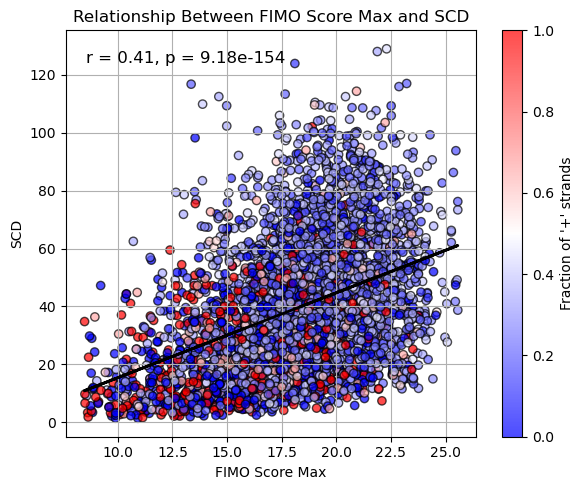

In [38]:
plt.figure(figsize=(6, 5))
plt.scatter(
    # grouped_df["score_sum"],
    grouped_df["score_max"],
    grouped_df["scd"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")

plt.plot(x, m*x + b, color="black", linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

# Add correlation text in upper left
plt.text(0.05, 0.95, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top')

plt.title("Relationship Between FIMO Score Max and SCD")
plt.xlabel("FIMO Score Max")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
# Compute Pearson correlation
r, p = pearsonr(grouped_df["score_sum"], grouped_df["scd"])
corr_text = f"r = {r:.2f}, p = {p:.2e}"

In [41]:
x = grouped_df["score_sum"]
y = grouped_df["scd"]

# Fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

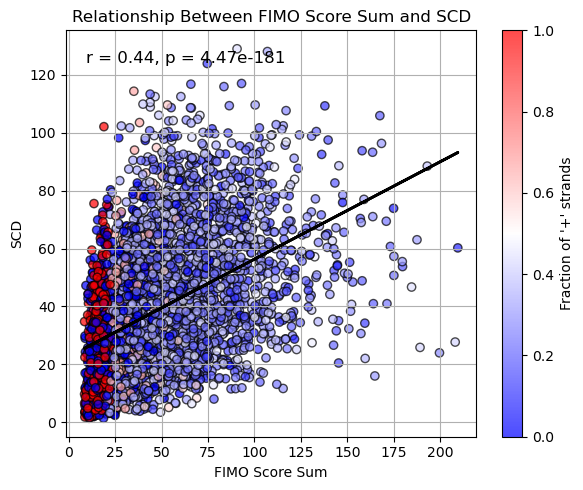

In [42]:
plt.figure(figsize=(6, 5))
plt.scatter(
    grouped_df["score_sum"],
    grouped_df["scd"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")

plt.plot(x, m*x + b, color="black", linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

# Add correlation text in upper left
plt.text(0.05, 0.95, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top')

plt.title("Relationship Between FIMO Score Sum and SCD")
plt.xlabel("FIMO Score Sum")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

### URQ mean vs. FIMO score (mean and max)

In [43]:
x = grouped_df["score_max"]
y = grouped_df["URQ_mean_og"]

# Fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

In [44]:
r, p = pearsonr(grouped_df["score_max"], grouped_df["URQ_mean_og"])
corr_text = f"r = {r:.2f}, p = {p:.2e}"

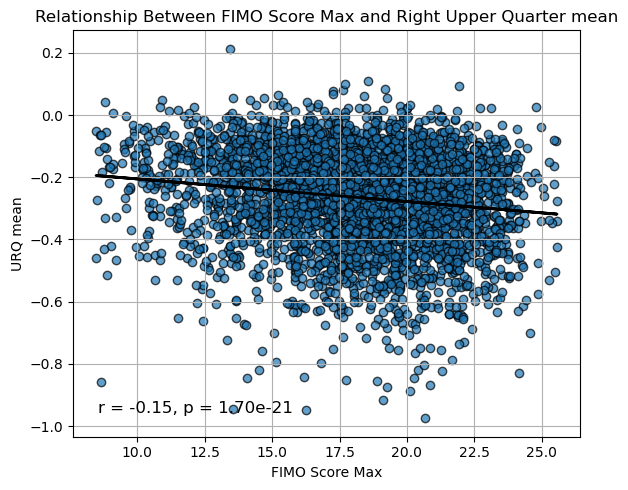

In [51]:
plt.figure(figsize=(6, 5))
plt.scatter(
    # grouped_df["score_sum"],
    grouped_df["score_max"],
    grouped_df["URQ_mean_og"],
    # c=grouped_df["strand_bias"],
    # cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
# plt.colorbar(label="Fraction of '+' strands")

plt.plot(x, m*x + b, color="black", linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

# Add correlation text in upper left
plt.text(0.05, 0.05, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom')

plt.title("Relationship Between FIMO Score Max and Right Upper Quarter mean")
plt.xlabel("FIMO Score Max")
plt.ylabel("URQ mean")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
grouped_df.columns

In [46]:
import seaborn as sns

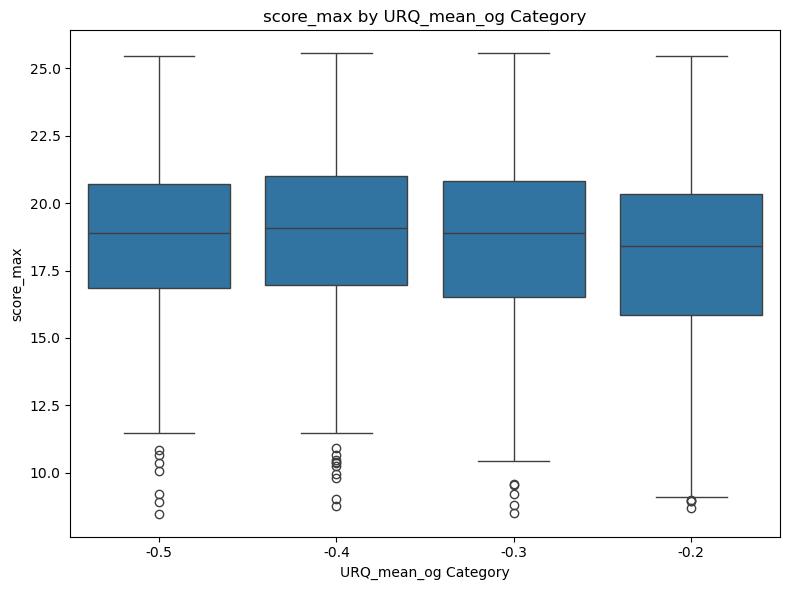

In [48]:
# Step 1: Define the bins and labels
bins = [-0.55, -0.45, -0.35, -0.25, -0.15]
labels = ['-0.5', '-0.4', '-0.3', '-0.2']

# Step 2: Create the category column
grouped_df['URQ_category'] = pd.cut(grouped_df['URQ_mean_og'], bins=bins, labels=labels, include_lowest=True)

# Step 3: Drop NaNs if any values fall outside the bin range
filtered_df = grouped_df.dropna(subset=['URQ_category'])

# Step 4: Plot the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='URQ_category', y='score_max', data=filtered_df)
plt.xlabel('URQ_mean_og Category')
plt.ylabel('score_max')
plt.title('score_max by URQ_mean_og Category')
plt.tight_layout()
plt.show()

In [ ]:
grouped_df

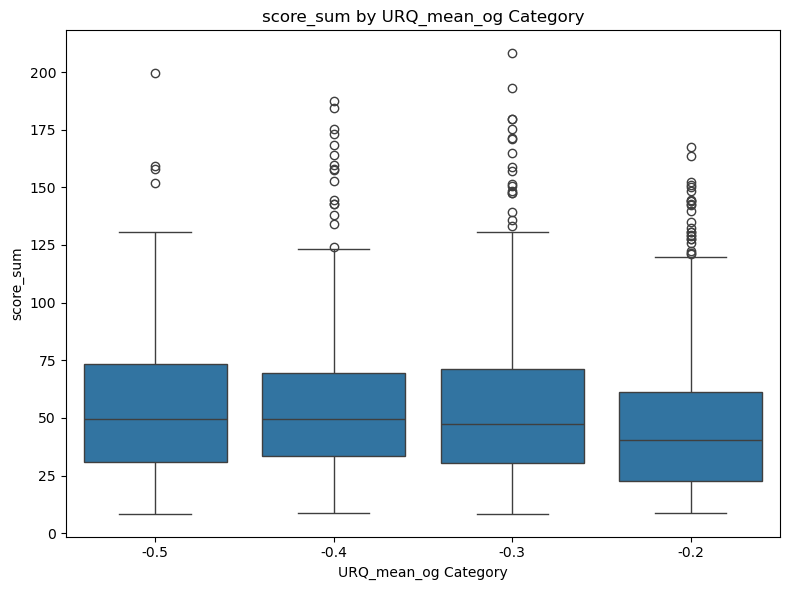

In [49]:
# Step 4: Plot the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='URQ_category', y='score_sum', data=filtered_df)
plt.xlabel('URQ_mean_og Category')
plt.ylabel('score_sum')
plt.title('score_sum by URQ_mean_og Category')
plt.tight_layout()
plt.show()

In [52]:
x = grouped_df["score_sum"]
y = grouped_df["URQ_mean_og"]

# Fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

In [53]:
r, p = pearsonr(grouped_df["score_sum"], grouped_df["URQ_mean_og"])
corr_text = f"r = {r:.2f}, p = {p:.2e}"

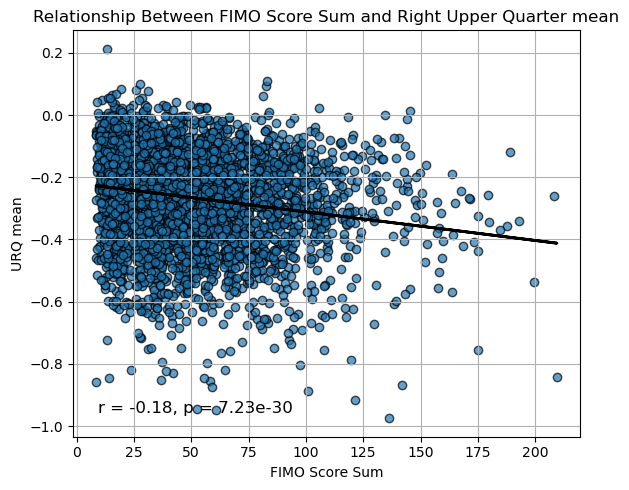

In [55]:
plt.figure(figsize=(6, 5))
plt.scatter(
    # grouped_df["score_sum"],
    grouped_df["score_sum"],
    grouped_df["URQ_mean_og"],
    # c=grouped_df["strand_bias"],
    # cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
# plt.colorbar(label="Fraction of '+' strands")

plt.plot(x, m*x + b, color="black", linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

# Add correlation text in upper left
plt.text(0.05, 0.05, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom')

plt.title("Relationship Between FIMO Score Sum and Right Upper Quarter mean")
plt.xlabel("FIMO Score Sum")
plt.ylabel("URQ mean")
plt.grid(True)
plt.tight_layout()
plt.show()